In [1]:
2+2

4

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)

In [6]:
sns.set_style("whitegrid")

In [8]:
df=pd.read_csv("german_credit_data.csv")

In [9]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [10]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [12]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [15]:
df.shape

(1000, 11)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 115.1 KB


In [20]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df["Job"].unique()

array([2, 1, 3, 0])

In [24]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [28]:
df=df.dropna().reset_index(drop=True)

In [29]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [30]:
df.drop(columns='Unnamed: 0', inplace=True)

In [32]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

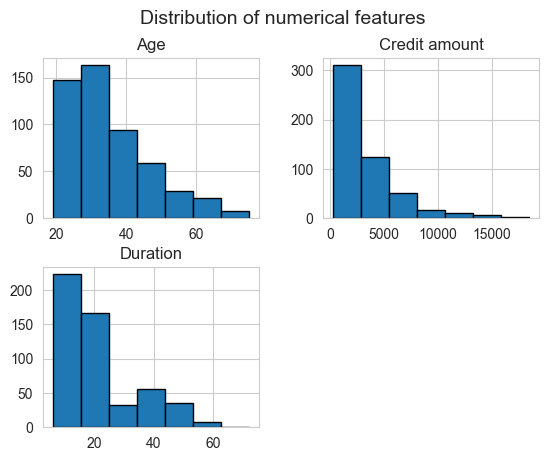

In [45]:
df[["Age","Credit amount","Duration",]].hist(bins=7, edgecolor="black")
plt.suptitle("Distribution of numerical features", fontsize=14)
plt.show()

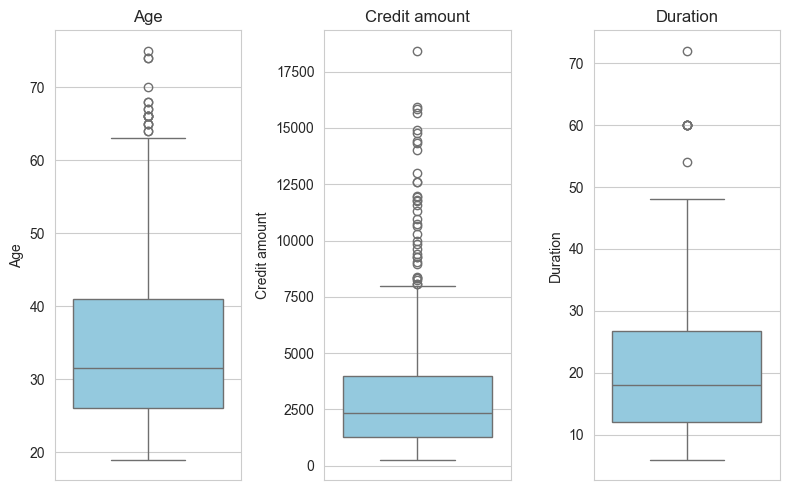

In [48]:
plt.figure(figsize=(8, 5))
for i, col in enumerate(("Age","Credit amount","Duration")):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()


In [54]:
df.query("Duration>=60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [55]:
categorial_cols=["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]

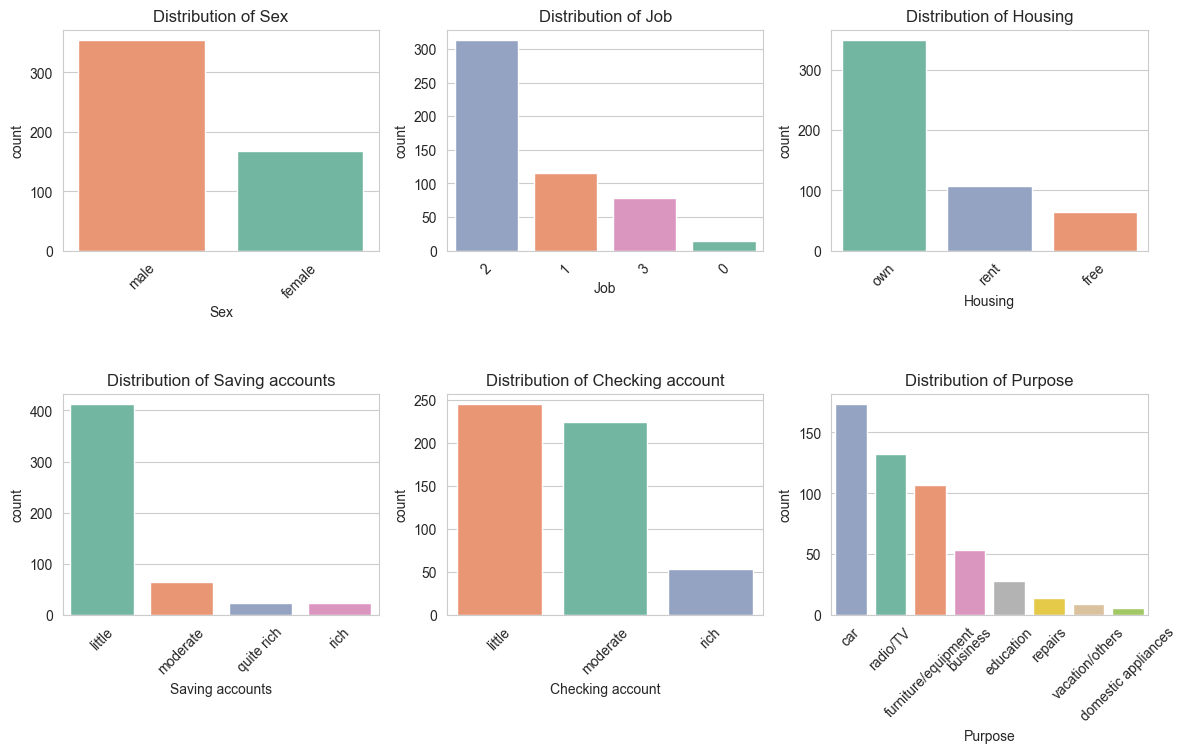

In [70]:
plt.figure(figsize=(12, 10))

for index, col in enumerate(categorial_cols):
    plt.subplot(3, 3, index+1)
    sns.countplot(x=col, data=df, palette="Set2",order=df[col].value_counts().index,hue=col,legend=False)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [72]:
corr = df[["Age","Job","Credit amount", "Duration"]].corr()

In [73]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


<Axes: >

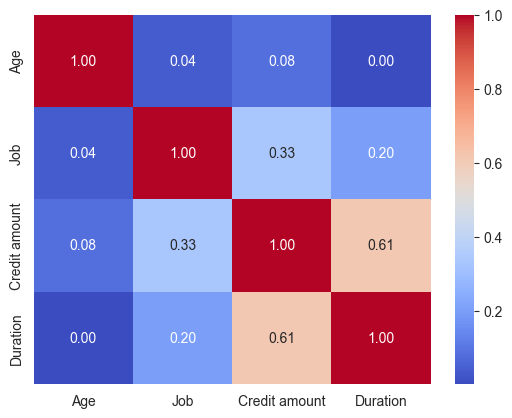

In [74]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

In [75]:
df.groupby("Job")["Credit amount"].mean() 

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [76]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [77]:
pd.pivot_table(df, values="Credit amount", index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


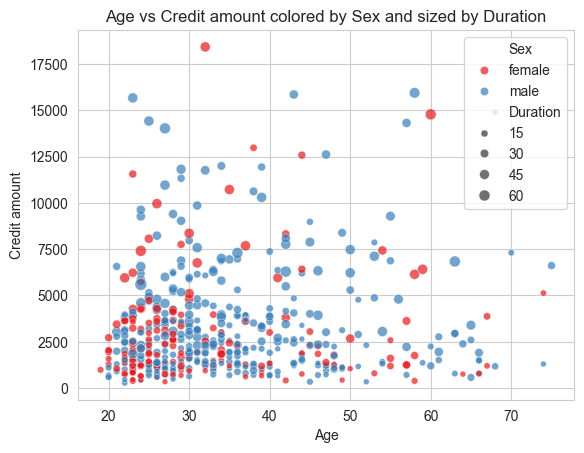

In [83]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex",size="Duration",alpha=0.7, palette="Set1")
plt.title("Age vs Credit amount colored by Sex and sized by Duration")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14092\3204767484.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Set3")


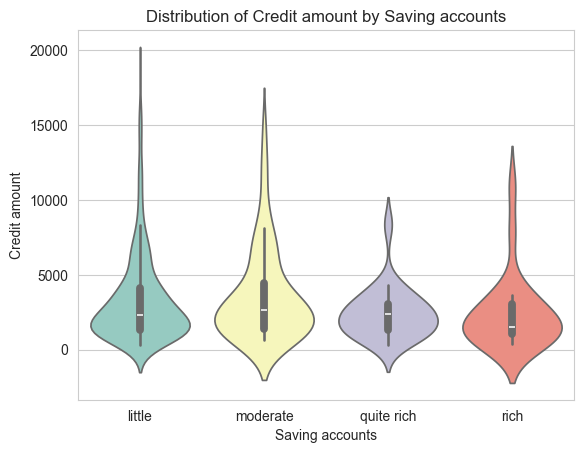

In [85]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Set3")
plt.title("Distribution of Credit amount by Saving accounts")
plt.show()

In [88]:
df["Risk"].value_counts(normalize=True)*100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

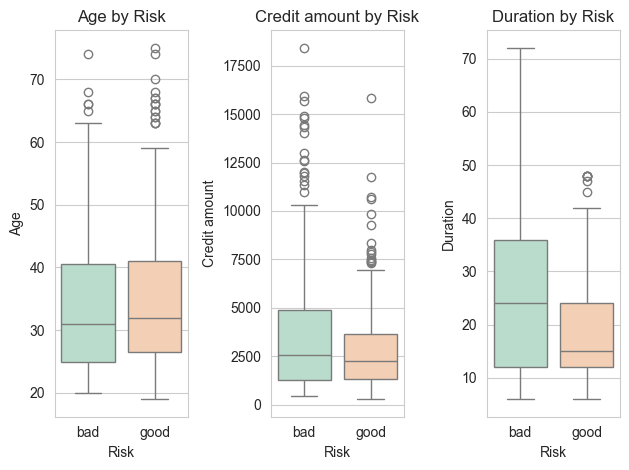

In [99]:
plt.Figure(figsize=(15, 4))

for i, col in enumerate(["Age","Credit amount","Duration"]):

    plt.subplot(1, 3, i+1)
    sns.boxplot(x="Risk", y=col, data=df, palette="Pastel2",hue="Risk",legend=False)
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [93]:
categorial_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

In [100]:
df.groupby("Risk")[["Age","Job","Credit amount", "Duration"]].mean()

,Age,Job,Credit amount,Duration
Risk,,,,
bad,34.147186,1.913420,3881.090909,25.445887
good,35.477663,1.845361,2800.594502,18.079038


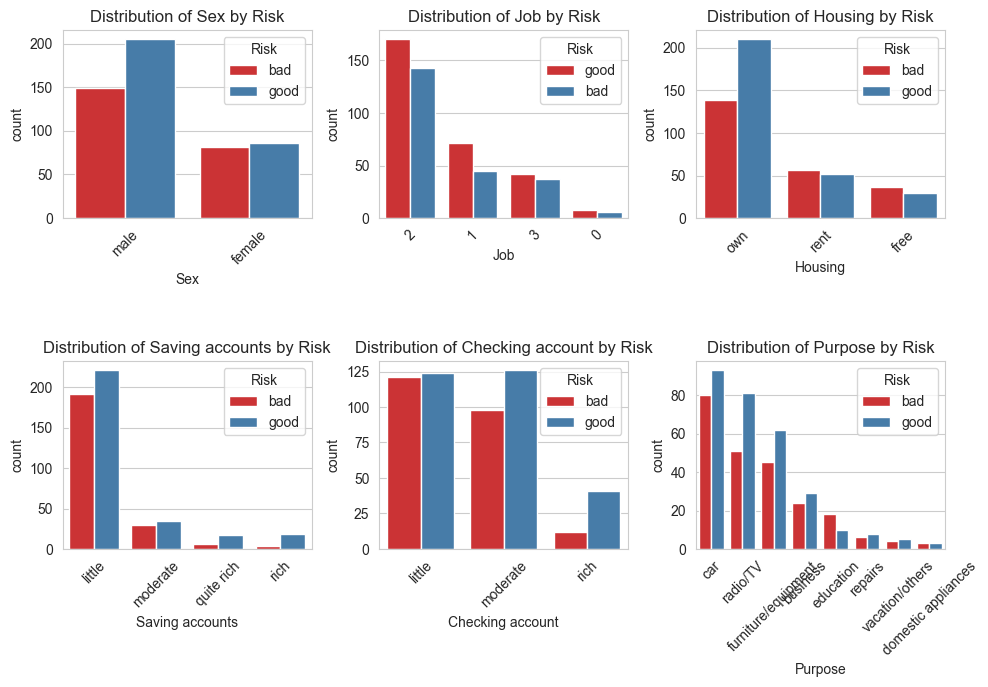

In [111]:
plt.figure(figsize=(10, 9))

for i, col in enumerate(categorial_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=col, data=df, palette="Set1",order=df[col].value_counts().index,hue="Risk")
    plt.title(f"Distribution of {col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [112]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [113]:
feature=["Age","Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration",]

In [114]:
target="Risk"

In [116]:
df_model=df[feature+[target]].copy()

In [118]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [120]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [121]:
cat_cols=df_model.select_dtypes(include="object").columns.drop("Risk")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14092\2637306855.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df_model.select_dtypes(include="object").columns.drop("Risk")


In [122]:
le_dict={}

In [123]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [125]:
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]=le
    joblib.dump(le, f"{col}_label_encoder.pkl")


In [126]:
le_target=LabelEncoder()

In [127]:
target

'Risk'

In [128]:
df_model[target]=le_target.fit_transform(df_model[target])

In [130]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [131]:
joblib.dump(le_target, "target_label_encoder.pkl")

['target_label_encoder.pkl']

In [132]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [133]:
from sklearn.model_selection import train_test_split

In [134]:
x=df_model.drop(target, axis=1)

In [135]:
y=df_model[target]

In [178]:
df["Saving accounts"].unique()

<ArrowStringArray>
['little', 'moderate', 'quite rich', 'rich']
Length: 4, dtype: str

In [182]:
df["Checking account"].unique()

<ArrowStringArray>
['moderate', 'little', 'rich']
Length: 3, dtype: str

In [136]:
x


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [138]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [139]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [140]:
X_train.shape

(417, 8)

In [141]:
X_test.shape

(105, 8)

In [145]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV


In [149]:
def train_model(model, param_grid, X_train, y_train,X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return best_model, accuracy,grid.best_params_

In [150]:
dt=DecisionTreeClassifier(random_state=1,class_weight="balanced")
dt_param_grid = {
    "max_depth": [3,5,7,10,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [151]:
best_dt,acc_dt,params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [152]:
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.6


In [153]:
print("Best Parameters:", params_dt)

Best Parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [157]:
rf=RandomForestClassifier(random_state=1,class_weight="balanced",n_jobs=-1)

In [158]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]

}

In [159]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [160]:
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.638095238095238


In [ ]:
print("Best Params:", params_rf)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}


In [163]:
et=ExtraTreesClassifier(random_state=1,class_weight="balanced",n_jobs=-1)

In [164]:
et_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]

}

In [165]:
best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [166]:
print("Extra Trees Accuracy:", acc_et)

Extra Trees Accuracy: 0.6095238095238096


In [167]:
print("Best Parameters:", params_et)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


In [169]:
xgb=XGBClassifier(random_state=1,scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),use_label_encoder=False, eval_metric='logloss')

In [170]:
xgb_param_grid = {
 "n_estimators": [100, 200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0]

}

In [171]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [03:04:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [172]:
print("XGB Accuracy:", acc_xgb)

XGB Accuracy: 0.6761904761904762


In [173]:
print("Best Parameters:", params_xgb)

Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


In [174]:
best_et.predict(X_test)

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0])

In [175]:
joblib.dump(best_et,"extra_trees_model.pkl")

['extra_trees_model.pkl']